# LiDAR processing step 2: MMDetection3D, conversion to BEV
- NOTE: Our BEV grid will be (x= [0, 250]m; y: [-90, 90]m, z: [-5, 3])
- we use resolution 0.2m along all three axes, small enough that the sparse3Dconv can make sense of pedestrians. 
--> 
- point_cloud_range = [0.0, -90.0, -5.0, 250.0, 90.0, 3.0]
- voxel_size = [0.2, 0.2, 0.2]
- grid_size = [1250, 900, 40] --> [1248, 896, 40]      # [x, y, z] (note we round in this way so that cnn won't reduce to decimal numbers)
- sparse_shape = [41, 900, 1250]   # [z+1, y, x]
- out_size_factor = 8

- z∈[-5,3] meters (MMDetection3D PointPillars nuScenes config uses this range for z-axis, so good place to start: https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html) 
- [-5, 3] is low enough to include road dips / slopes and high enough to include pedestrians, cars, poles, and other near-road objects. We are essentially restricting the z-axis to a physically relevant region to save compute.

- points -> voxelization -> HardSimpleVFE -> SparseEncoder -> SECOND -> SECONDFPN



UPDATED VERSION:
point_cloud_range: [0.0, -54.0, -5.0, 108.0, 54.0, 3.0]
voxel_size: [0.075, 0.075, 0.2]
grid_size [x, y, z]: [1440, 1440, 40]
sparse_shape [x, y, z]: [1440, 1440, 41]


In [ ]:
# ============================================================
# Load BEV LiDAR points saved as .bin
# ============================================================

import numpy as np
from pathlib import Path

# Path to saved file
bin_path = Path("/home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin")

# ------------------------------------------------------------
# Read raw binary float32 values
# ------------------------------------------------------------

raw = np.fromfile(bin_path, dtype=np.float32)
print(f"raw.shape: {raw.shape}")

# ------------------------------------------------------------
# Reshape into (N,4) → [x,y,z,intensity]
# ------------------------------------------------------------

fov_points_ego_xyzi = raw.reshape(-1, 4)
print(f"fov_points_ego_xyzi.shape: {fov_points_ego_xyzi.shape}")

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Loaded file:", bin_path)
print("Dtype:", fov_points_ego_xyzi.dtype)
print("First point:", fov_points_ego_xyzi[0] if len(fov_points_ego_xyzi) else "EMPTY")


raw.shape: (295532,)
fov_points_ego_xyzi.shape: (73883, 4)
Loaded file: /home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin
Dtype: float32
First point: [47.478405 56.58517   8.407365 62.      ]


In [ ]:
import sys
MMDET3D_ROOT = "/home/edgelab/mmdetection3d"
if MMDET3D_ROOT not in sys.path:
    sys.path.insert(0, MMDET3D_ROOT)

In [ ]:
# ============================================================
# Imports + coherent LiDAR spatial config for BEVFusion lidar stack
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from mmengine.registry import init_default_scope
from mmcv.ops import Voxelization

from mmdet3d.models.voxel_encoders import HardSimpleVFE
from projects.BEVFusion.bevfusion.sparse_encoder import BEVFusionSparseEncoder
from mmdet3d.models.backbones import SECOND
from mmdet3d.models.necks import SECONDFPN

init_default_scope("mmdet3d")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ------------------------------------------------------------
# Your chosen detection range
# ------------------------------------------------------------
X_MIN, Y_MIN, Z_MIN = 0.0, -54.0, -5.0
X_MAX, Y_MAX, Z_MAX = 108.0, 54.0, 3.0

point_cloud_range = [X_MIN, Y_MIN, Z_MIN, X_MAX, Y_MAX, Z_MAX]

# ------------------------------------------------------------
# chosen grid
# ------------------------------------------------------------
# rounding the grid so it is divisible by powers of 2, common in CNN pipelines
# avoids fractional feature map sizes after downsampling
NX = 1440 # number of voxels along x (forward direction) 250/0.2 = 1250 --> 1248
NY = 1440 # number of voxels along y (lateral direction) 180/0.2 = 900 --> 896
NZ = 40 # number of voxels along z (height direction) 8/0.2 = 40 --> 40


VOXEL_X = (X_MAX - X_MIN) / NX # voxel size in x direction
VOXEL_Y = (Y_MAX - Y_MIN) / NY # voxel size in y direction
VOXEL_Z = (Z_MAX - Z_MIN) / NZ # voxel size in z direction

voxel_size = [VOXEL_X, VOXEL_Y, VOXEL_Z]

# ------------------------------------------------------------
# For BEVFusionSparseEncoder in this setup we keep sparse_shape
# in [X, Y, Z(+1)].
# ------------------------------------------------------------
grid_size = [NX, NY, NZ]
#sparse_shape defines the maximum spatial extent of the sparse tensor inside the sparse CNN.
# It must be large enough to contain every voxel coordinate that appears in coors.
# sparse convolution layers can temporarily create padding voxels at the boundary
# so we need to account for this in the sparse_shape by adding 1 to the z-dimension.
# most sparse padding occurs in the z-dimention, which is collapsed anyways in the SECOND backbone.
sparse_shape = [NX, NY, NZ + 1]

print("point_cloud_range:", point_cloud_range)
print("voxel_size:", voxel_size)
print("grid_size [x, y, z]:", grid_size)
print("sparse_shape [x, y, z]:", sparse_shape)

device: cuda
point_cloud_range: [0.0, -90.0, -5.0, 180.0, 90.0, 3.0]
voxel_size: [0.125, 0.125, 0.2]
grid_size [x, y, z]: [1440, 1440, 40]
sparse_shape [x, y, z]: [1440, 1440, 41]


In [15]:
# ============================================================
# Load ego-frame XYZI points and filter to the voxel region
# ============================================================

pts_xyzi = fov_points_ego_xyzi.astype(np.float32)
print("Raw fov_points_ego_xyzi shape:", pts_xyzi.shape)

# filter points to the voxel region
mask = (
    (pts_xyzi[:, 0] >= X_MIN) & (pts_xyzi[:, 0] < X_MAX) &
    (pts_xyzi[:, 1] >= Y_MIN) & (pts_xyzi[:, 1] < Y_MAX) &
    (pts_xyzi[:, 2] >= Z_MIN) & (pts_xyzi[:, 2] < Z_MAX)
)

pts_xyzi = pts_xyzi[mask]
print("Points after filtering:", pts_xyzi.shape)
# points_tensor is the input to the voxelizer
points_tensor = torch.from_numpy(pts_xyzi).to(device)
print("Points passed to voxelizer:", tuple(points_tensor.shape))

Raw fov_points_ego_xyzi shape: (73883, 4)
Points after filtering: (51313, 4)
Points passed to voxelizer: (51313, 4)


In [16]:
# ============================================================
# LiDAR front-end:
# points -> voxels -> HardSimpleVFE -> BEVFusionSparseEncoder
#         -> dense BEV feature map
# ============================================================

voxel_layer = Voxelization(
    voxel_size=voxel_size,
    point_cloud_range=point_cloud_range,
    max_num_points=10,
    max_voxels=(200000, 240000),
)

voxel_encoder = HardSimpleVFE(
    num_features=4
).to(device).eval()

middle_encoder = BEVFusionSparseEncoder(
    in_channels=4,
    sparse_shape=sparse_shape, # [x, y, z]: [1248, 896, 41], defines the full voxel grid size (but only the occupied voxels are stored)
    order=("conv", "norm", "act"), # conv → batchnorm → activation
    norm_cfg=dict(type="BN1d", eps=1e-3, momentum=0.01),
    base_channels=16, # sets width of the first conv layer
    output_channels=128, # sets width of the last conv layer
    encoder_channels=((16, 16, 32), (32, 32, 64), (64, 64, 128), (128, 128)), # sets the width of the intermediate conv layers
    encoder_paddings=((0, 0, 1), (0, 0, 1), (0, 0, (1, 1, 0)), (0, 0)),
    block_type="basicblock",
).to(device).eval()

with torch.no_grad():
    # --------------------------------------------------------
    # Hard voxelization
    # --------------------------------------------------------
    voxels, coors, num_points = voxel_layer(points_tensor)
    # voxels: [voxel_num, max_points_per_voxel, D = 4] (only keeps nonempty voxels.. voxel_num <= max_voxels)
    # max_points_per_voxel = 10 (hardcoded in Voxelization layer)
    # coors: [voxel_num, 3] (z, y, x)
    # num_points: [voxel_num] (number of points in each voxel)

    print("voxels shape:", tuple(voxels.shape))
    print("coors shape:", tuple(coors.shape))
    print("num_points shape:", tuple(num_points.shape))
    print("first 10 raw coors rows:")
    #print(coors[:10].cpu().numpy())

    # --------------------------------------------------------
    # Build batch coords for HardSimpleVFE
    #
    # The voxelizer usually returns coors in [z, y, x].
    # HardSimpleVFE is fine with batch + raw coors.
    # --------------------------------------------------------
    batch_idx = torch.zeros((coors.shape[0], 1), dtype=coors.dtype, device=coors.device)
    coors_batch_vfe = torch.cat([batch_idx, coors], dim=1)   # [b, z, y, x]

    # --------------------------------------------------------
    # Per-voxel feature encoding (HardSimpleVFE -> voxel_features, simple average pooling across points in each voxel)
    # --------------------------------------------------------
    voxel_features = voxel_encoder(voxels, num_points, coors_batch_vfe)
    # voxel_features shape: [voxel_num, D=4]

    # --------------------------------------------------------
    # Reorder coordinates for BEVFusionSparseEncoder
    #
    # Raw voxelizer coors are typically:
    #   coors[:, 0] = z
    #   coors[:, 1] = y
    #   coors[:, 2] = x
    #
    # For this BEVFusionSparseEncoder setup, we reorder them to:
    #   [batch, x, y, z]
    # so they match sparse_shape = [NX, NY, NZ+1]
    # --------------------------------------------------------
    coors_xyz = torch.stack(
        [coors[:, 2], coors[:, 1], coors[:, 0]],
        dim=1
    )  # [x, y, z]

    coors_batch_bevfusion = torch.cat([batch_idx, coors_xyz], dim=1)  # [b, x, y, z]

    #print("first 10 reordered coors rows for BEVFusion:")
    #print(coors_batch_bevfusion[:10].cpu().numpy())

    # --------------------------------------------------------
    # Sparse encoder -> dense BEV feature map:
    # sparse voxels in 3D
    # ↓
    # 3D sparse convolution backbone
    # ↓
    # collapse vertical dimension
    # ↓
    # dense BEV feature map [C, H, W]
    # --------------------------------------------------------
    bev_feature_map = middle_encoder(
        voxel_features, #[M, 4]
        coors_batch_bevfusion, #[M, 4] -> [batch, x, y, z]
        batch_size=1
    )

    print("coors_batch_vfe shape:", tuple(coors_batch_vfe.shape))
    print("coors_batch_bevfusion shape:", tuple(coors_batch_bevfusion.shape))
    print("voxel_features shape:", tuple(voxel_features.shape))
    print("bev_feature_map shape:", tuple(bev_feature_map.shape)) # [1, 256, H_bev, W_bev]
    print("BEV mean activation:", bev_feature_map.mean().item())
    print("BEV std activation:", bev_feature_map.std().item())

voxels shape: (31903, 10, 4)
coors shape: (31903, 3)
num_points shape: (31903,)
first 10 raw coors rows:
coors_batch_vfe shape: (31903, 4)
coors_batch_bevfusion shape: (31903, 4)
voxel_features shape: (31903, 4)
bev_feature_map shape: (1, 256, 180, 180)
BEV mean activation: 1.3812686461278645e-07
BEV std activation: 1.1076076589233708e-06


In [17]:
print("bev_feature_map shape:", tuple(bev_feature_map.shape))
_, C_bev, H_bev, W_bev = bev_feature_map.shape
print("H_bev:", H_bev, "W_bev:", W_bev)
print("Expected from grid: NY =", NY, "NX =", NX)

bev_feature_map shape: (1, 256, 180, 180)
H_bev: 180 W_bev: 180
Expected from grid: NY = 1440 NX = 1440


bev_feature_map shape: (1, 256, 180, 180)
2D summary shape before transpose: (180, 180)


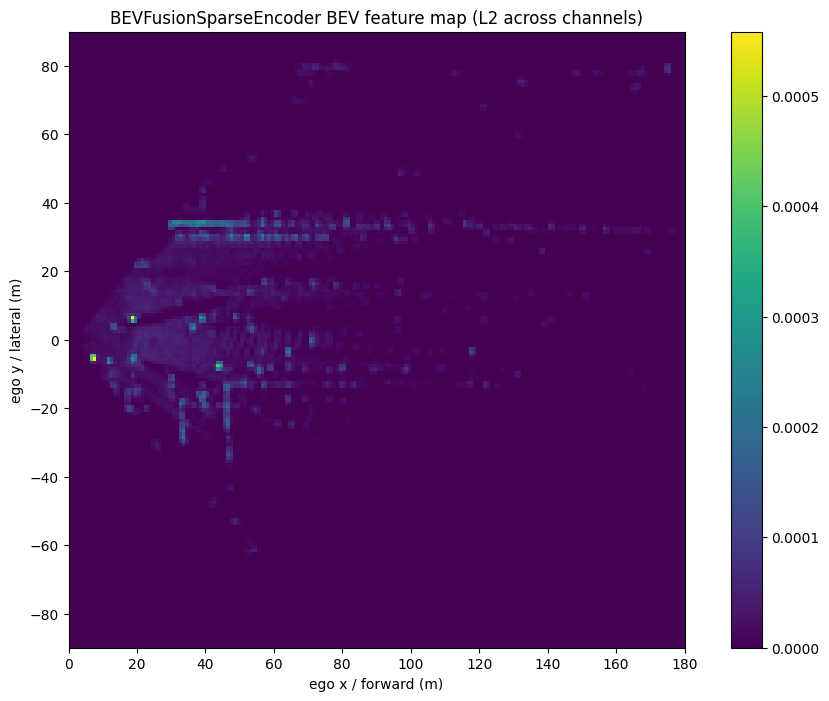

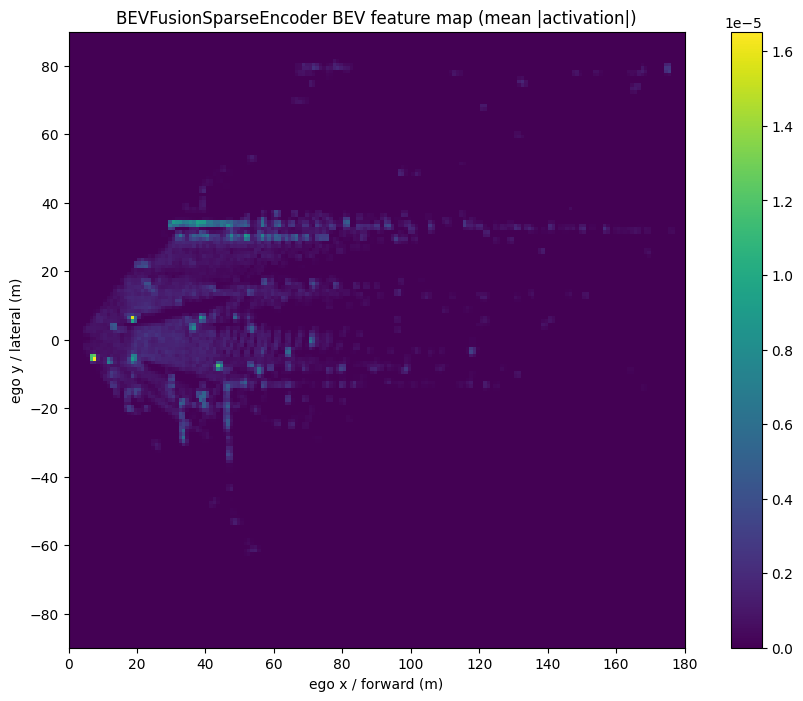

In [18]:
# ============================================================
# Visualize the dense BEV feature map from BEVFusionSparseEncoder
#
# IMPORTANT SHAPE CONVENTION:
# bev_feature_map has shape:
#   [B, C, X_reduced, Y_reduced]
#
# So after collapsing channels, the 2D summaries have shape:
#   [X_reduced, Y_reduced]
#
# However, matplotlib.imshow expects a 2D image in:
#   [rows, cols] = [Y, X]
#
# Therefore, we transpose the 2D map before plotting:
#   [X, Y] -> [Y, X]
#
# The plotted axes are still ego-frame coordinates:
#   x-axis = ego forward
#   y-axis = ego lateral
# ============================================================

bev = bev_feature_map.detach().cpu()[0]   # [C, X_reduced, Y_reduced]

# Collapse channel dimension to get 2D summaries of the BEV tensor
bev_l2_xy = torch.norm(bev, dim=0).numpy()        # [X_reduced, Y_reduced] this is the L2 norm of the BEV feature map
bev_mean_xy = bev.abs().mean(dim=0).numpy()       # [X_reduced, Y_reduced] this is the mean of the absolute values of the BEV feature map

extent = [X_MIN, X_MAX, Y_MIN, Y_MAX]

print("bev_feature_map shape:", tuple(bev_feature_map.shape))
print("2D summary shape before transpose:", bev_l2_xy.shape)

# ------------------------------------------------------------
# Plot L2 summary across channels
# Transpose is needed because imshow expects [Y, X], while the
# encoder output summary here is [X, Y].
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))
plt.imshow(
    bev_l2_xy.T,
    origin="lower",
    extent=extent,
    aspect="equal"
)
plt.title("BEVFusionSparseEncoder BEV feature map (L2 across channels)")
plt.xlabel("ego x / forward (m)")
plt.ylabel("ego y / lateral (m)")
plt.colorbar()
plt.show()

# ------------------------------------------------------------
# Plot mean absolute activation across channels
# Again, transpose [X, Y] -> [Y, X] for visualization.
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))
plt.imshow(
    bev_mean_xy.T,
    origin="lower",
    extent=extent,
    aspect="equal"
)
plt.title("BEVFusionSparseEncoder BEV feature map (mean |activation|)")
plt.xlabel("ego x / forward (m)")
plt.ylabel("ego y / lateral (m)")
plt.colorbar()
plt.show()

In [19]:
print(bev_feature_map.shape)


torch.Size([1, 256, 180, 180])


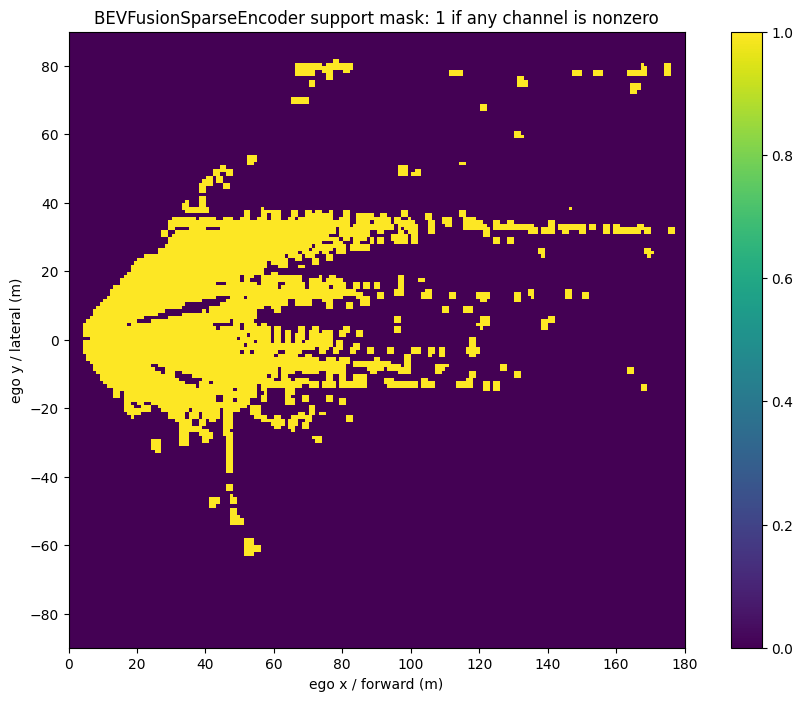

In [20]:
# ============================================================
# Visualize encoder support in BEV
#
# bev_feature_map: [B, C, X_reduced, Y_reduced]
# support map:     [X_reduced, Y_reduced]
#
# We transpose to [Y, X] before plotting with imshow.
# ============================================================

bev_support_xy = (bev.abs().sum(dim=0) > 0).numpy().astype(np.float32)  # [X_reduced, Y_reduced]

plt.figure(figsize=(12, 8))
plt.imshow(
    bev_support_xy.T,
    origin="lower",
    extent=extent,
    aspect="equal"
)
plt.title("BEVFusionSparseEncoder support mask: 1 if any channel is nonzero")
plt.xlabel("ego x / forward (m)")
plt.ylabel("ego y / lateral (m)")
plt.colorbar()
plt.show()

In [21]:
# ============================================================
# Run SECOND backbone + SECONDFPN neck on the BEV feature map
#
# Input tensor structure:
#   bev_feature_map = [B, C, X_reduced, Y_reduced]
#
# SECOND treats the spatial dimensions like an image:
#   height = X dimension
#   width  = Y dimension
#
# This is fine for convolution, but when plotting we must
# transpose to match matplotlib's [Y, X] convention.
# ============================================================

print("Input BEV tensor shape: [B, C, X_reduced, Y_reduced]", tuple(bev_feature_map.shape)) #[B, C, X_reduced, Y_reduced]

bev_backbone = SECOND(
    in_channels=256,   # matches BEVFusionSparseEncoder output
    out_channels=[128, 256], # stage 1 and 2 output channels
    layer_nums=[5, 5], # stage 1 and 2 num of layers
    layer_strides=[1, 2], # stage 1 and 2 strides
    norm_cfg=dict(type="BN", eps=1e-3, momentum=0.01), # batchnorm
    conv_cfg=dict(type="Conv2d", bias=False), # conv2d
).to(device).eval()

# SECONDFPN: 
# First Channel transform:
# [1,128,156,112] → [1,256,156,112] 
# [1,256,78,56]   → [1,256,78,56]
# Then spatial alignment (upsampling): 
# [1,256,78,56] → [1,256,156,112]
# [1,256,156,112] → [1,256,156,112]
# Then concatenate along channel dimension:
# [1,256,156,112] + [1,256,156,112] = [1,512,156,112]

bev_neck = SECONDFPN(
    in_channels=[128, 256],
    out_channels=[256, 256], # The neck transforms both input feature maps so that both become 256-channel outputs --> compatible for fusion. 
    upsample_strides=[1, 2], 
    norm_cfg=dict(type="BN", eps=1e-3, momentum=0.01),
    upsample_cfg=dict(type="deconv", bias=False),
    use_conv_for_no_stride=True,
).to(device).eval()

with torch.no_grad():

    # Multi-scale BEV features from SECOND
    backbone_feats = bev_backbone(bev_feature_map)
    # backbone_feats[0]  = higher resolution
    # backbone_feats[1]  = lower resolution

    # Fused BEV features from FPN
    neck_feats = bev_neck(backbone_feats)
    # neck_feats[0] ≈ transformed high-res branch
    # neck_feats[1] ≈ upsampled transformed low-res branch

    print("\nBackbone feature maps:")
    for i, feat in enumerate(backbone_feats):
        print(f"  backbone_feats[{i}] shape:", tuple(feat.shape))

    print("\nNeck feature maps:")
    for i, feat in enumerate(neck_feats):
        print(f"  neck_feats[{i}] shape:", tuple(feat.shape))

Input BEV tensor shape: [B, C, X_reduced, Y_reduced] (1, 256, 180, 180)

Backbone feature maps:
  backbone_feats[0] shape: (1, 128, 180, 180)
  backbone_feats[1] shape: (1, 256, 90, 90)

Neck feature maps:
  neck_feats[0] shape: (1, 512, 180, 180)



SECOND backbone outputs:
  backbone_feats[0] shape: (1, 128, 180, 180)


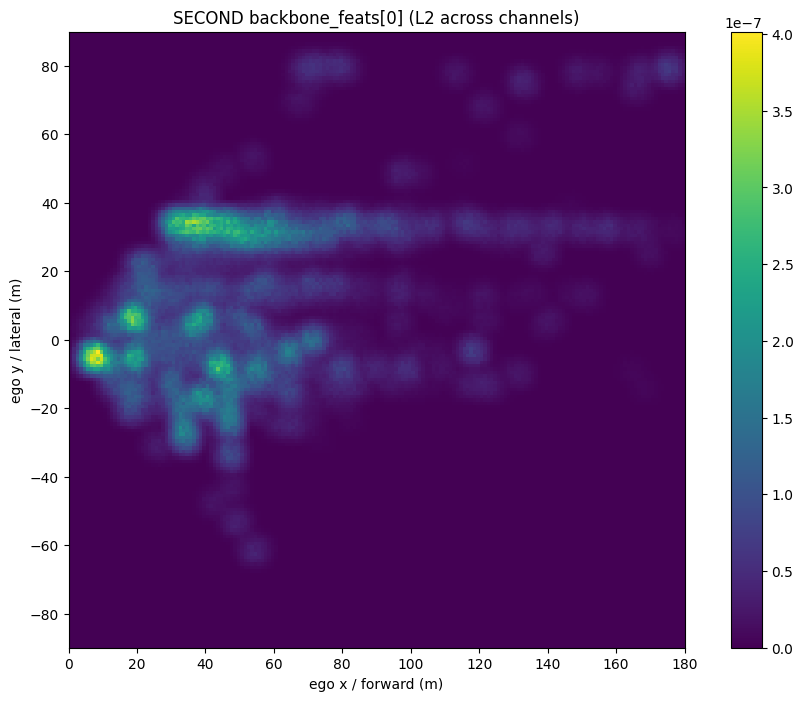

  backbone_feats[1] shape: (1, 256, 90, 90)


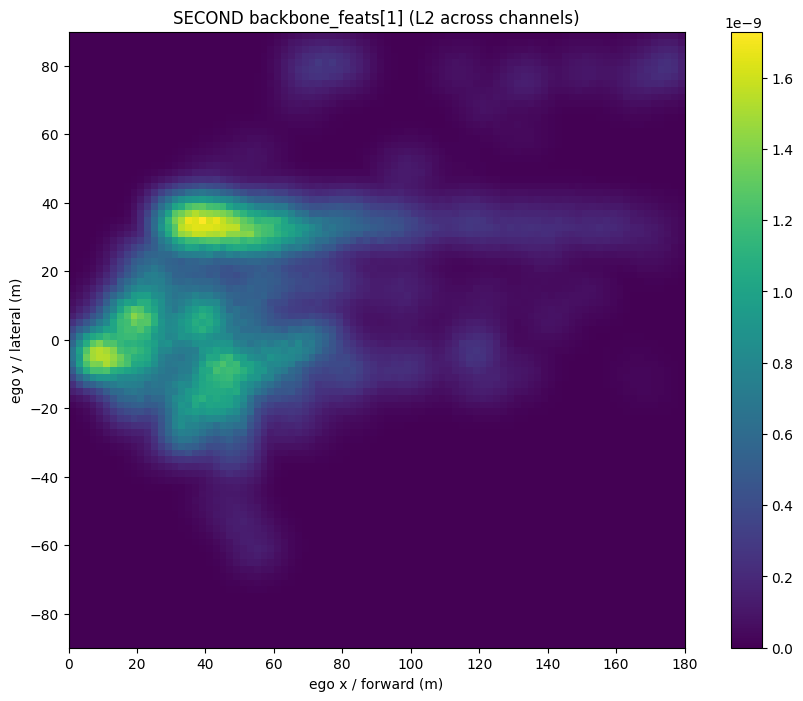


SECONDFPN fused output shape: (1, 512, 180, 180)
  neck branch 0 shape: (1, 256, 180, 180)
  neck branch 1 shape: (1, 256, 180, 180)


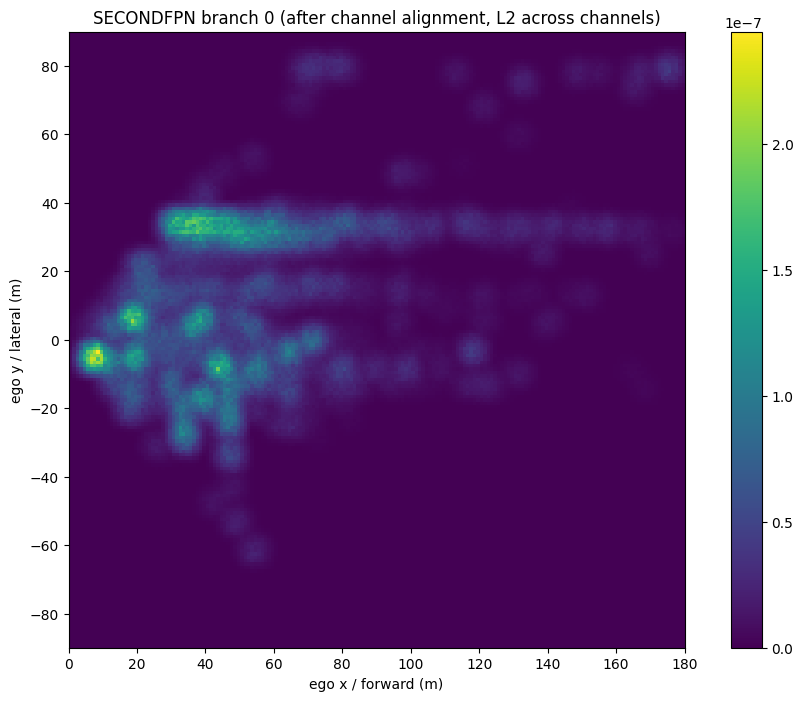

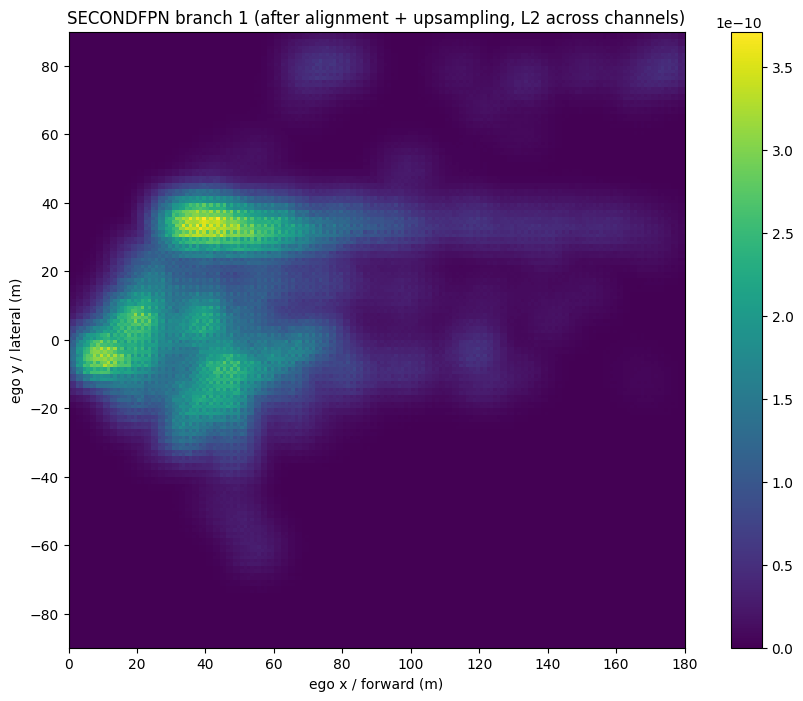

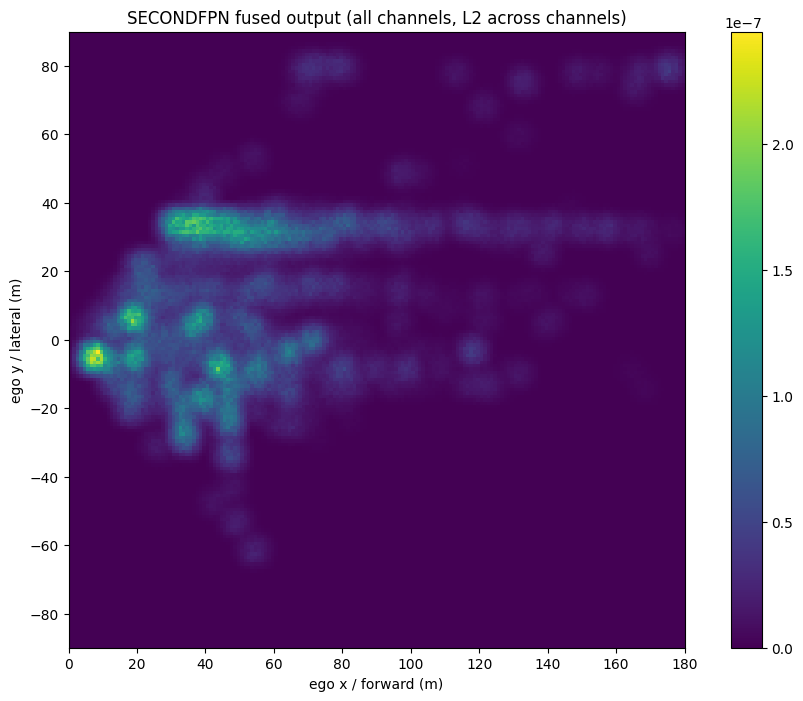

In [22]:
# ============================================================
# Visualize SECOND + SECONDFPN feature maps in ego-frame
#
# Tensor spatial layout:
#   feature_tensor = [B, C, X_reduced, Y_reduced]
#
# We summarize each feature tensor by taking the L2 norm across
# channels, producing:
#   l2_xy = [X_reduced, Y_reduced]
#
# For matplotlib we convert:
#   [X, Y] -> [Y, X]
# using transpose before plotting.
# ============================================================

def summarize_bev_feature_l2(x):
    """
    Convert a BEV feature tensor to a 2D L2 summary.

    Input
        x : [1, C, X, Y]

    Returns
        l2_xy : [X, Y]
    """
    x = x.detach().cpu()[0]          # [C, X, Y]
    l2_xy = torch.norm(x, dim=0).numpy()
    return l2_xy


def plot_bev_xy(arr_xy, title):
    """
    Plot BEV tensor stored as [X, Y].

    Convert to [Y, X] for matplotlib.
    """
    plt.figure(figsize=(12, 8))
    plt.imshow(
        arr_xy.T,
        origin="lower",
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        aspect="equal"
    )
    plt.title(title)
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()


# ------------------------------------------------------------
# 1) SECOND backbone outputs
# ------------------------------------------------------------
print("\nSECOND backbone outputs:")
for i, feat in enumerate(backbone_feats):
    print(f"  backbone_feats[{i}] shape:", tuple(feat.shape))
    l2_xy = summarize_bev_feature_l2(feat)
    plot_bev_xy(
        l2_xy,
        f"SECOND backbone_feats[{i}] (L2 across channels)"
    )


# ------------------------------------------------------------
# 2) SECONDFPN internal branches
#
# Assumption:
#   neck_feats[0] is the final fused tensor after concatenation:
#       [1, 512, X, Y]
#
# Since SECONDFPN uses two 256-channel branches, we split:
#   [:, :256, :, :]   -> branch 0 after channel alignment
#   [:, 256:, :, :]   -> branch 1 after channel alignment + upsampling
# ------------------------------------------------------------
fused_neck = neck_feats[0]

print("\nSECONDFPN fused output shape:", tuple(fused_neck.shape))

neck_branch_0 = fused_neck[:, :256, :, :]
neck_branch_1 = fused_neck[:, 256:, :, :]

print("  neck branch 0 shape:", tuple(neck_branch_0.shape))
print("  neck branch 1 shape:", tuple(neck_branch_1.shape))

# Branch 0: aligned high-resolution branch
l2_xy = summarize_bev_feature_l2(neck_branch_0)
plot_bev_xy(
    l2_xy,
    "SECONDFPN branch 0 (after channel alignment, L2 across channels)"
)

# Branch 1: aligned low-resolution branch after upsampling
l2_xy = summarize_bev_feature_l2(neck_branch_1)
plot_bev_xy(
    l2_xy,
    "SECONDFPN branch 1 (after alignment + upsampling, L2 across channels)"
)

# Final fused output: all 512 channels together
l2_xy = summarize_bev_feature_l2(fused_neck)
plot_bev_xy(
    l2_xy,
    "SECONDFPN fused output (all channels, L2 across channels)"
)

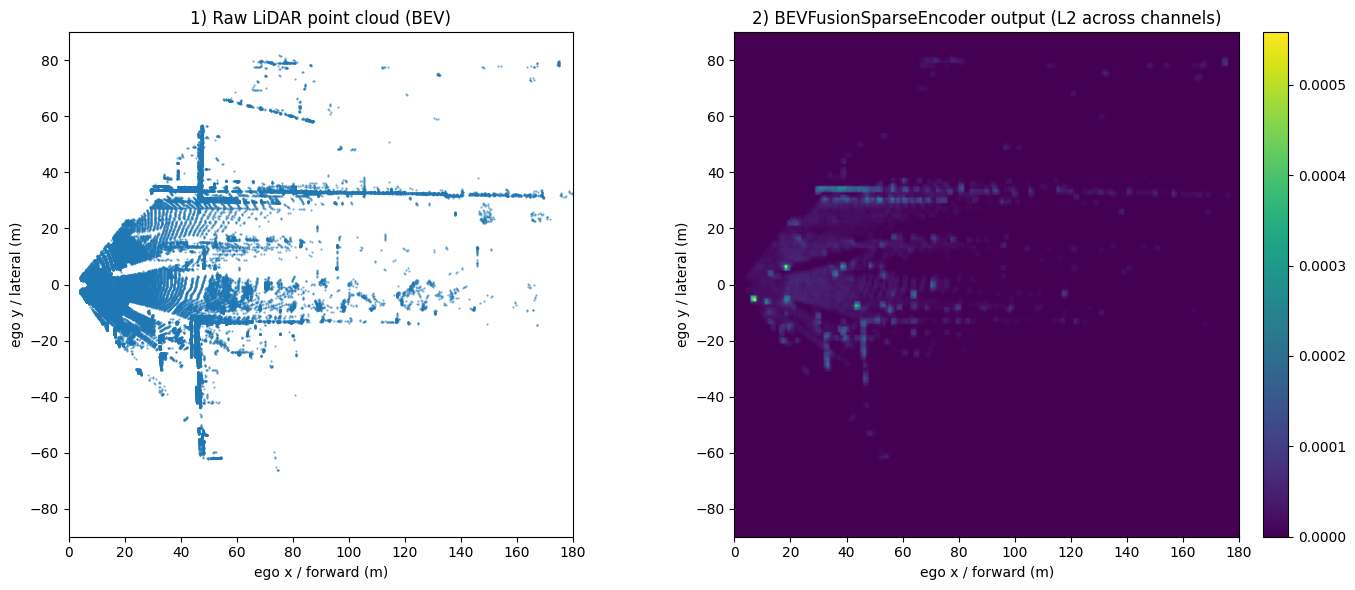

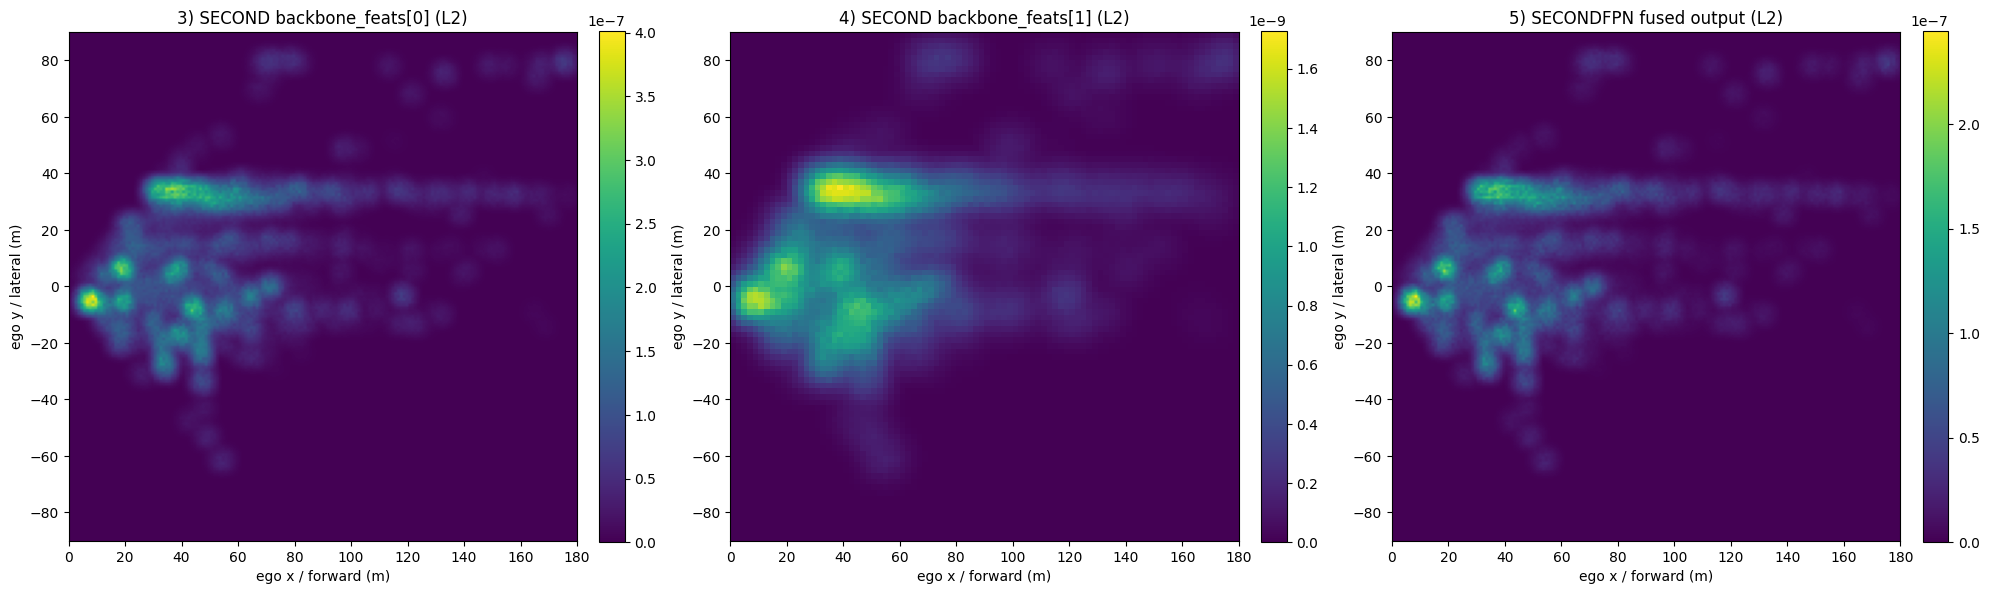

Raw LiDAR points: (73883, 4)
BEVFusionSparseEncoder output: (1, 256, 180, 180)
SECOND backbone_feats[0]: (1, 128, 180, 180)
SECOND backbone_feats[1]: (1, 256, 90, 90)
SECONDFPN fused output: (1, 512, 180, 180)


: 

In [ ]:
# ============================================================
# Visualize progression of LiDAR processing
#
# Figure 1:
#   1) Raw LiDAR point cloud (BEV)
#   2) BEVFusionSparseEncoder BEV feature map (L2)
#
# Figure 2:
#   3) SECOND backbone_feats[0] (L2)
#   4) SECOND backbone_feats[1] (L2)
#   5) SECONDFPN fused output (L2)
#
# Assumptions:
#   fov_points_ego_xyzi : numpy [N, >=3]
#   bev_feature_map     : [1, C, X, Y]
#   backbone_feats      : list of tensors
#   neck_feats          : list where neck_feats[0] is fused output
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


def summarize_bev_feature_l2(x):
    """Convert [1, C, X, Y] tensor into L2 map [X, Y]."""
    x = x.detach().cpu()[0]      # [C, X, Y]
    l2_xy = torch.norm(x, dim=0)
    return l2_xy.numpy()


def plot_bev_xy(ax, arr_xy, title):
    """Plot BEV tensor stored as [X, Y]."""
    im = ax.imshow(
        arr_xy.T,
        origin="lower",
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        aspect="equal",
        cmap="viridis"
    )
    ax.set_title(title)
    ax.set_xlabel("ego x / forward (m)")
    ax.set_ylabel("ego y / lateral (m)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def plot_lidar_bev(ax, points_xyzi, title):
    """Scatter raw LiDAR points in BEV."""
    x = points_xyzi[:, 0]
    y = points_xyzi[:, 1]

    ax.scatter(x, y, s=0.3, alpha=0.6)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect("equal")

    ax.set_title(title)
    ax.set_xlabel("ego x / forward (m)")
    ax.set_ylabel("ego y / lateral (m)")


# ============================================================
# Compute L2 summaries
# ============================================================

bev_sparse_l2 = summarize_bev_feature_l2(bev_feature_map)

backbone0_l2 = summarize_bev_feature_l2(backbone_feats[0])
backbone1_l2 = summarize_bev_feature_l2(backbone_feats[1])

fused_neck = neck_feats[0]
fused_neck_l2 = summarize_bev_feature_l2(fused_neck)


# ============================================================
# FIGURE 1: Raw LiDAR → Sparse BEV
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_lidar_bev(
    axes[0],
    fov_points_ego_xyzi,
    "1) Raw LiDAR point cloud (BEV)"
)

plot_bev_xy(
    axes[1],
    bev_sparse_l2,
    "2) BEVFusionSparseEncoder output (L2 across channels)"
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2: Learned BEV feature hierarchy
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_bev_xy(
    axes[0],
    backbone0_l2,
    "3) SECOND backbone_feats[0] (L2)"
)

plot_bev_xy(
    axes[1],
    backbone1_l2,
    "4) SECOND backbone_feats[1] (L2)"
)

plot_bev_xy(
    axes[2],
    fused_neck_l2,
    "5) SECONDFPN fused output (L2)"
)

plt.tight_layout()
plt.show()


# ============================================================
# Shape sanity checks
# ============================================================

print("Raw LiDAR points:", fov_points_ego_xyzi.shape)
print("BEVFusionSparseEncoder output:", tuple(bev_feature_map.shape))
print("SECOND backbone_feats[0]:", tuple(backbone_feats[0].shape))
print("SECOND backbone_feats[1]:", tuple(backbone_feats[1].shape))
print("SECONDFPN fused output:", tuple(fused_neck.shape))